<a href="https://colab.research.google.com/github/shruthilakshmi008-BA/ba-automation-suite/blob/main/05.%20KPI-Dashboard-Generator/05_KPI_Dashboard_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q google-genai pandas matplotlib

In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

from google import genai
from google.colab import files, userdata


# Load Gemini API key securely from Colab Secrets
GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError(
        "GEMINI_API_KEY not found. "
        "Please add it under Colab → Secrets."
    )

client = genai.Client(api_key=GEMINI_API_KEY)

print("Gemini API key loaded successfully.")
print("Gemini client initialized successfully.")

Gemini API key loaded successfully.
Gemini client initialized successfully.


In [3]:
uploaded = files.upload()

input_file = list(uploaded.keys())[0]

print(f"Input file uploaded: {input_file}")

Saving ops_data.csv to ops_data.csv
Input file uploaded: ops_data.csv


In [4]:
## Read Input + Compute KPIs
df = pd.read_csv(input_file)

print("Input data loaded successfully.")
print(f"Total records: {len(df)}")

display(df.head())


def compute_kpis(df: pd.DataFrame) -> dict:
    """Deterministic math layer calculating overall and categorical metrics."""

    total_records = len(df)

    avg_turnaround = float(
        df["turnaround_days"].mean()
    )

    avg_sla = float(
        df["sla_days"].mean()
    )

    # Identify SLA breaches
    df["is_breach"] = (
        df["turnaround_days"] > df["sla_days"]
    )

    over_sla_pct = float(
        df["is_breach"].mean() * 100
    )

    # Category level aggregation
    category_summary = {}

    for cat, group in df.groupby("category"):

        category_summary[cat] = {
            "volume": int(len(group)),

            "avg_turnaround": round(
                float(
                    group["turnaround_days"].mean()
                ),
                2
            ),

            "avg_sla": round(
                float(
                    group["sla_days"].mean()
                ),
                2
            ),

            "breach_rate_pct": round(
                float(
                    group["is_breach"].mean() * 100
                ),
                1
            )
        }

    return {
        "overall": {
            "total_records": total_records,

            "avg_turnaround_days": round(
                avg_turnaround,
                2
            ),

            "avg_sla_target": round(
                avg_sla,
                2
            ),

            "overall_pct_over_sla": round(
                over_sla_pct,
                1
            ),
        },

        "by_category": category_summary
    }


kpis = compute_kpis(df)

print("\nKPI calculation completed.")
print(json.dumps(kpis, indent=2))

Input data loaded successfully.
Total records: 12


,claim_id,category,turnaround_days,sla_days
0,1,Travel,2,3
1,2,Travel,4,3
2,3,Meals,1,2
3,4,Equipment,6,5
4,5,Software,3,3



KPI calculation completed.
{
  "overall": {
    "total_records": 12,
    "avg_turnaround_days": 3.67,
    "avg_sla_target": 3.25,
    "overall_pct_over_sla": 41.7
  },
  "by_category": {
    "Equipment": {
      "volume": 3,
      "avg_turnaround": 7.0,
      "avg_sla": 5.0,
      "breach_rate_pct": 100.0
    },
    "Meals": {
      "volume": 3,
      "avg_turnaround": 1.33,
      "avg_sla": 2.0,
      "breach_rate_pct": 0.0
    },
    "Software": {
      "volume": 2,
      "avg_turnaround": 2.5,
      "avg_sla": 3.0,
      "breach_rate_pct": 0.0
    },
    "Travel": {
      "volume": 4,
      "avg_turnaround": 3.5,
      "avg_sla": 3.0,
      "breach_rate_pct": 50.0
    }
  }
}


In [5]:
##Generate KPI Dashboard Charts
def generate_dashboard_charts(
    df: pd.DataFrame,
    output_path: str
):
    """Generates a multi-panel executive KPI dashboard visualization."""

    plt.style.use(
        "seaborn-v0_8-whitegrid"
        if "seaborn-v0_8-whitegrid"
        in plt.style.available
        else "default"
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(16, 4.5)
    )

    # Data preparation
    counts = df["category"].value_counts()

    df["is_breach"] = (
        df["turnaround_days"] >
        df["sla_days"]
    )

    breach_rates = (
        df.groupby("category")["is_breach"]
        .mean() * 100
    )

    turnaround_vs_sla = (
        df.groupby("category")[
            ["turnaround_days", "sla_days"]
        ].mean()
    )

    # Panel 1: Operational Volume
    axes[0].bar(
        counts.index,
        counts.values,
        color="#2b5c8f",
        width=0.55
    )

    axes[0].set_title(
        "Operational Volume by Category",
        fontsize=11,
        fontweight="bold"
    )

    axes[0].set_ylabel(
        "Record Count"
    )

    axes[0].tick_params(
        axis="x",
        rotation=30
    )

    # Panel 2: SLA Breach Rate
    axes[1].barh(
        breach_rates.index,
        breach_rates.values,
        color="#d9534f",
        height=0.55
    )

    axes[1].set_title(
        "SLA Breach Rate (%) by Category",
        fontsize=11,
        fontweight="bold"
    )

    axes[1].set_xlabel(
        "Breach Rate %"
    )

    axes[1].set_xlim(
        0,
        100
    )

    # Panel 3: Turnaround vs SLA
    turnaround_vs_sla.plot(
        kind="bar",
        ax=axes[2],
        color=[
            "#f0ad4e",
            "#5cb85c"
        ],
        width=0.6
    )

    axes[2].set_title(
        "Avg Turnaround vs. Target SLA (Days)",
        fontsize=11,
        fontweight="bold"
    )

    axes[2].set_ylabel(
        "Days"
    )

    axes[2].tick_params(
        axis="x",
        rotation=30
    )

    axes[2].legend([
        "Actual Avg",
        "SLA Target"
    ])

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(
        f"Multi-Panel KPI Dashboard saved to: "
        f"{output_path}"
    )


chart_path = "kpi_dashboard.png"

generate_dashboard_charts(
    df,
    chart_path
)

Multi-Panel KPI Dashboard saved to: kpi_dashboard.png


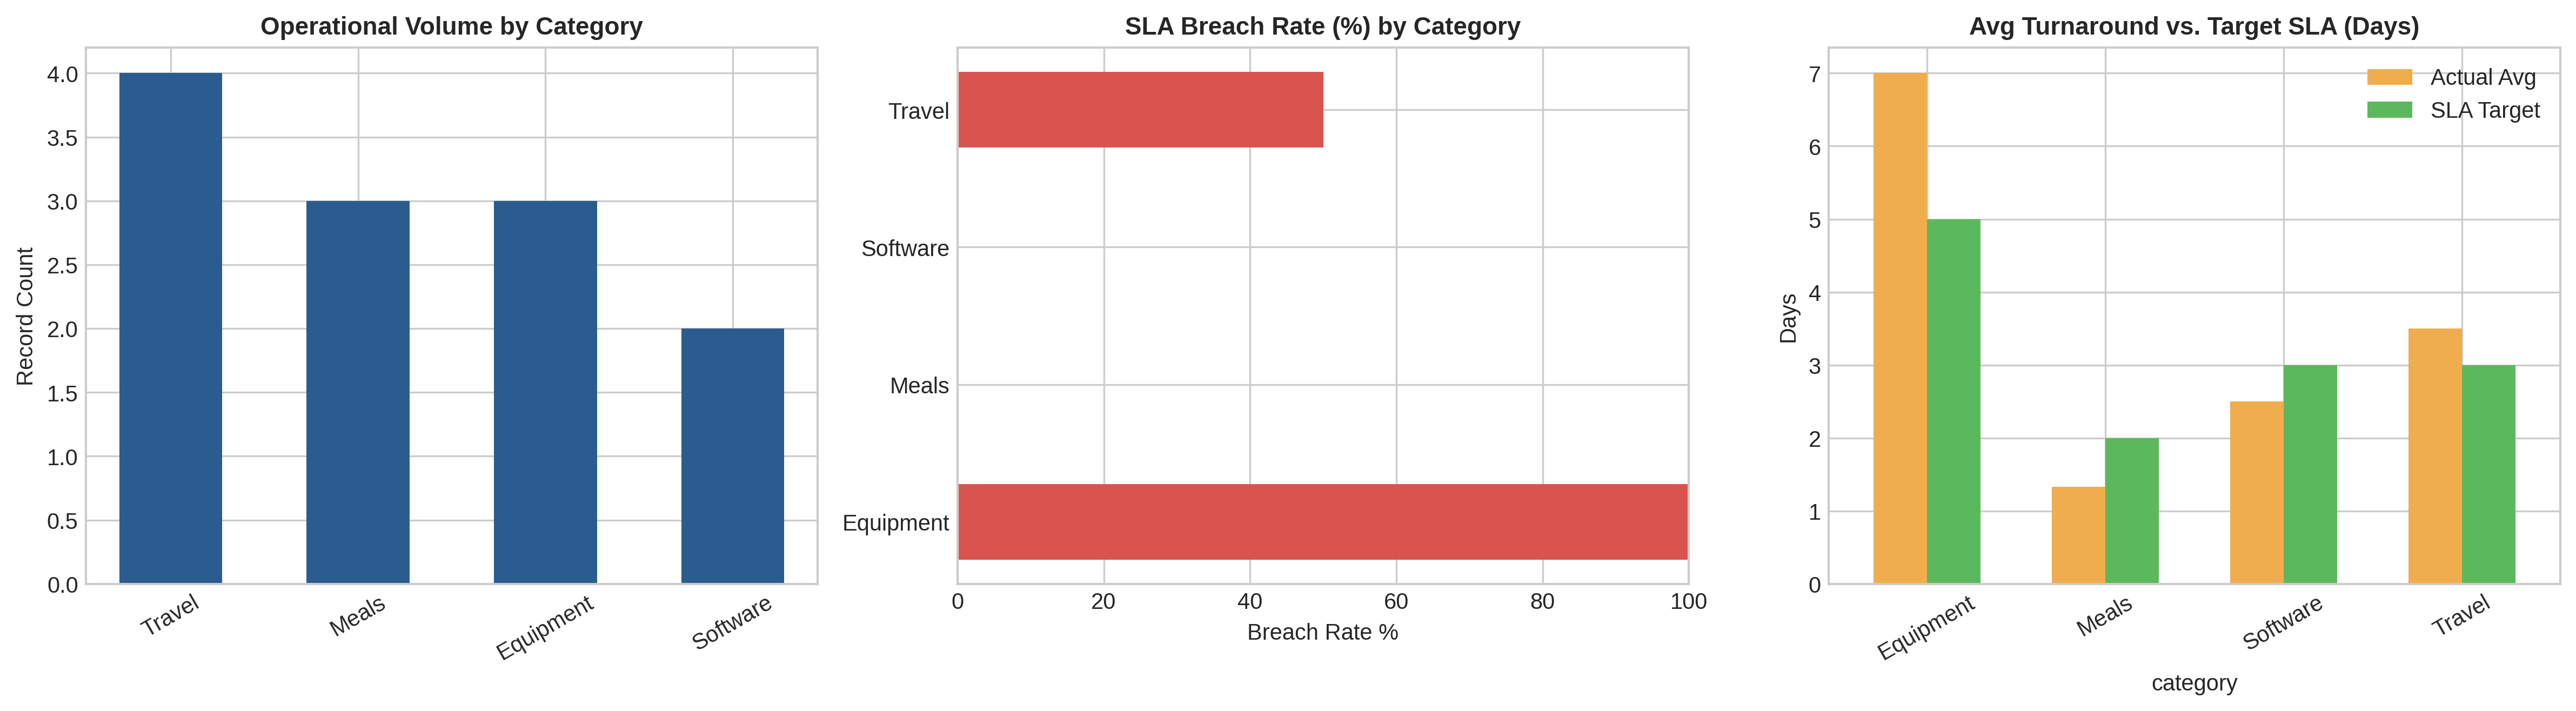

In [6]:
##Display the Generated Dashboard
from IPython.display import Image, display

display(Image(filename=chart_path))

In [7]:
##Generate Executive Narrative with Gemini
def generate_ai_narrative(
    kpis: dict
) -> str:

    try:

        print(
            "[AI Pipeline] Generating Executive "
            "Briefing via Gemini..."
        )

        prompt = f"""
You are a Lead Operations Business Analyst.

Analyze the following KPI dataset:

{json.dumps(kpis, indent=2)}

Provide a concise executive brief.

Format the response exactly as:

**Executive Takeaway:**
1-2 sentences summarizing overall operational performance.

**Operational Bottlenecks:**
Highlight specific high-risk or high-SLA-breach categories.

**Recommended Actions:**
Provide concrete business analyst recommendations
for process improvement.

Base all insights strictly on the provided KPI data.

Do not invent metrics or information.
"""

        response = client.models.generate_content(
            model="gemini-3.6-flash",
            contents=prompt
        )

        return response.text.strip()

    except Exception as e:

        print(
            f"[Gemini Warning] Narrative generation failed: "
            f"{e}"
        )

        print(
            "[Fallback] Using deterministic KPI narrative."
        )

        return None

In [8]:
##Add Fallback + Generate Narrative
def generate_fallback_narrative(
    kpis: dict
) -> str:

    cats = kpis["by_category"]

    worst_breach_cat = max(
        cats,
        key=lambda c: cats[c]["breach_rate_pct"]
    )

    top_vol_cat = max(
        cats,
        key=lambda c: cats[c]["volume"]
    )

    return (
        f"**Executive Takeaway:** "
        f"Across {kpis['overall']['total_records']} "
        f"processed records, average processing time "
        f"was {kpis['overall']['avg_turnaround_days']} "
        f"days against an overall SLA benchmark of "
        f"{kpis['overall']['avg_sla_target']} days, "
        f"yielding an overall SLA breach rate of "
        f"{kpis['overall']['overall_pct_over_sla']}%.\n\n"

        f"**Operational Bottlenecks:** "
        f"'{worst_breach_cat}' experienced the highest "
        f"SLA failure rate at "
        f"{cats[worst_breach_cat]['breach_rate_pct']}%, "
        f"while '{top_vol_cat}' represented the largest "
        f"total operational volume "
        f"({cats[top_vol_cat]['volume']} records).\n\n"

        f"**Recommended Actions:** "
        f"Prioritize workflow optimization and resource "
        f"allocation within the '{worst_breach_cat}' "
        f"and '{top_vol_cat}' processes to achieve "
        f"immediate SLA compliance recovery."
    )


narrative = generate_ai_narrative(kpis)

if narrative is None:
    narrative = generate_fallback_narrative(kpis)

print("\n=================== OPERATIONAL KPI BRIEFING ===================")

print(
    f"Total Volume         : "
    f"{kpis['overall']['total_records']} items"
)

print(
    f"Average Turnaround   : "
    f"{kpis['overall']['avg_turnaround_days']} days"
)

print(
    f"SLA Target Benchmark : "
    f"{kpis['overall']['avg_sla_target']} days"
)

print(
    f"Overall SLA Breach   : "
    f"{kpis['overall']['overall_pct_over_sla']}%"
)

print("----------------------------------------------------------------")

print("EXECUTIVE NARRATIVE:")
print(narrative)

print("================================================================")

[AI Pipeline] Generating Executive Briefing via Gemini...

=================== OPERATIONAL KPI BRIEFING ===================
Total Volume         : 12 items
Average Turnaround   : 3.67 days
SLA Target Benchmark : 3.25 days
Overall SLA Breach   : 41.7%
----------------------------------------------------------------
EXECUTIVE NARRATIVE:
**Executive Takeaway:**
Overall operations are currently underperforming, yielding an average turnaround time of 3.67 days against a 3.25-day SLA target and an overall SLA breach rate of 41.7% across 12 total records. This underperformance is driven entirely by significant processing delays within specific request categories.

**Operational Bottlenecks:**
* **Equipment:** Critical bottleneck with a 100.0% breach rate, averaging 7.0 turnaround days against a 5.0-day SLA target across 3 records.
* **Travel:** Secondary bottleneck representing the highest volume (4 records), with a 50.0% breach rate and an average turnaround of 3.5 days exceeding the 3.0-day

In [9]:
##Save CSV + Download CSV and Dashboard
output_csv = "kpi_summary.csv"

summary_data = {
    "total_records": [
        kpis["overall"]["total_records"]
    ],

    "avg_turnaround_days": [
        kpis["overall"]["avg_turnaround_days"]
    ],

    "avg_sla_target": [
        kpis["overall"]["avg_sla_target"]
    ],

    "overall_pct_over_sla": [
        kpis["overall"]["overall_pct_over_sla"]
    ],

    "executive_narrative": [
        narrative
    ]
}


pd.DataFrame(summary_data).to_csv(
    output_csv,
    index=False,
    encoding="utf-8"
)


print(f"Saved CSV Summary: {output_csv}")
print(f"Saved Dashboard: {chart_path}")


# Download both files
files.download(output_csv)
files.download(chart_path)

Saved CSV Summary: kpi_summary.csv
Saved Dashboard: kpi_dashboard.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>